# EDA Orientado al Modelado — Morosidad Arancelaria UNSTA

Este notebook parte del dataset ya limpio y procesado (`dataset_morosidad_limpio.csv`) generado en `eda_morosidad.ipynb`.  
El objetivo no es volver a limpiar datos sino **entender los patrones que guiarán las decisiones del modelo**:

1. Balance de clases y estrategia ante el imbalance
2. Distribución de features vs `target_mora_genuina`
3. Patrones estacionales (cuota, mes, semestre)
4. Correlaciones y multicolinealidad
5. Integración con datos reales 2025/2026 (deudores actuales)
6. Conclusiones → features a usar, descartar, estrategia de modelado

## 1. Setup e imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (14, 5)

DATA_DIR = Path('../training/data')

print('Setup OK')

Setup OK


## 2. Carga del dataset limpio

In [ ]:
df = pd.read_csv(
    DATA_DIR / 'dataset_morosidad_limpio.csv',
    parse_dates=['fecha_vencimiento', 'fecha_pago', 'venc_1_real', 'venc_2_real', 'venc_3_real'],
    low_memory=False
)

print(f'Filas:    {len(df):,}')
print(f'Columnas: {df.shape[1]}')
print(f'Períodos: {sorted(df["periodo"].unique())}')
print(f'Alumnos únicos: {df["id_alumno"].nunique():,}')
print()
print('=== Columnas disponibles ===')
for col in df.columns:
    print(f'  {col}: {df[col].dtype}  | nulos: {df[col].isna().sum()}')

Filas:    451,921
Columnas: 65
Períodos: [2020, 2021, 2022, 2023, 2024, 2025]
Alumnos únicos: 24,148

=== Columnas disponibles ===
  id_alumno: int64  | nulos: 0
  id_persona: int64  | nulos: 0
  periodo: int64  | nulos: 0
  nro_cuota: int64  | nulos: 0
  fecha_vencimiento: datetime64[ns]  | nulos: 0
  id_carrera: object  | nulos: 0
  id_sede_academica: int64  | nulos: 0
  id_unidad_academica: int64  | nulos: 0
  id_facultad: object  | nulos: 0
  id_categoria_arancelaria: int64  | nulos: 0
  pct_descuento: float64  | nulos: 0
  cod_categoria: object  | nulos: 0
  sexo: object  | nulos: 419
  edad_al_vencer: float64  | nulos: 7694
  discapacidad: int64  | nulos: 0
  id_localidad: float64  | nulos: 399534
  id_provincia: float64  | nulos: 399138
  contexto_temporal: object  | nulos: 0
  fecha_pago: datetime64[ns]  | nulos: 139567
  nro_venc_usado: float64  | nulos: 139567
  dias_atraso: float64  | nulos: 139567
  target_no_pago: int64  | nulos: 0
  inicio_mes: object  | nulos: 0
  venc_1

In [ ]:
# Targets disponibles
TARGET_COLS = ['target_mora_genuina', 'target_pago_mes', 'target_impago', 'target_no_pago']
print('=== Distribución de targets ===')
for t in TARGET_COLS:
    if t in df.columns:
        vc = df[t].value_counts(dropna=False)
        pct = df[t].value_counts(normalize=True, dropna=False) * 100
        print(f'\n{t}:')
        for v in vc.index:
            print(f'  {v}: {vc[v]:>8,}  ({pct[v]:.1f}%)')

=== Distribución de targets ===

target_mora_genuina:
  1:  252,955  (56.0%)
  0:  198,966  (44.0%)

target_pago_mes:
  0:  356,020  (78.8%)
  1:   95,901  (21.2%)

target_impago:
  0:  417,021  (92.3%)
  1:   34,900  (7.7%)

target_no_pago:
  1:  325,770  (72.1%)
  0:  126,151  (27.9%)


## 3. Balance de clases y estrategia de imbalance

Antes de analizar features, entendemos el desbalance del target principal `target_mora_genuina`.

In [ ]:
TARGET = 'target_mora_genuina'
df_modelo = df[df[TARGET].notna()].copy()

n_total = len(df_modelo)
n_mora  = df_modelo[TARGET].sum()
n_ok    = n_total - n_mora
ratio   = n_ok / n_mora

print(f'Dataset para modelado: {n_total:,} filas')
print(f'  Sin mora  (0): {n_ok:>8,}  ({n_ok/n_total*100:.1f}%)')
print(f'  Con mora  (1): {n_mora:>8,}  ({n_mora/n_total*100:.1f}%)')
print(f'  Ratio positivo/negativo: 1 : {ratio:.2f}')
print()

# Distribucion por año
print('=== Tasa de mora genuina por período ===')
by_periodo = df_modelo.groupby('periodo')[TARGET].agg(['mean','sum','count'])
by_periodo.columns = ['tasa_mora', 'n_mora', 'n_total']
by_periodo['tasa_mora_pct'] = (by_periodo['tasa_mora'] * 100).round(1)
print(by_periodo[['n_total','n_mora','tasa_mora_pct']].to_string())

Dataset para modelado: 451,921 filas
  Sin mora  (0):  198,966  (44.0%)
  Con mora  (1):  252,955  (56.0%)
  Ratio positivo/negativo: 1 : 0.79

=== Tasa de mora genuina por período ===
         n_total  n_mora  tasa_mora_pct
periodo                                
2020       63215   42477           67.2
2021       69848   41855           59.9
2022       78103   45272           58.0
2023       87718   47293           53.9
2024       85007   44047           51.8
2025       68030   32011           47.1


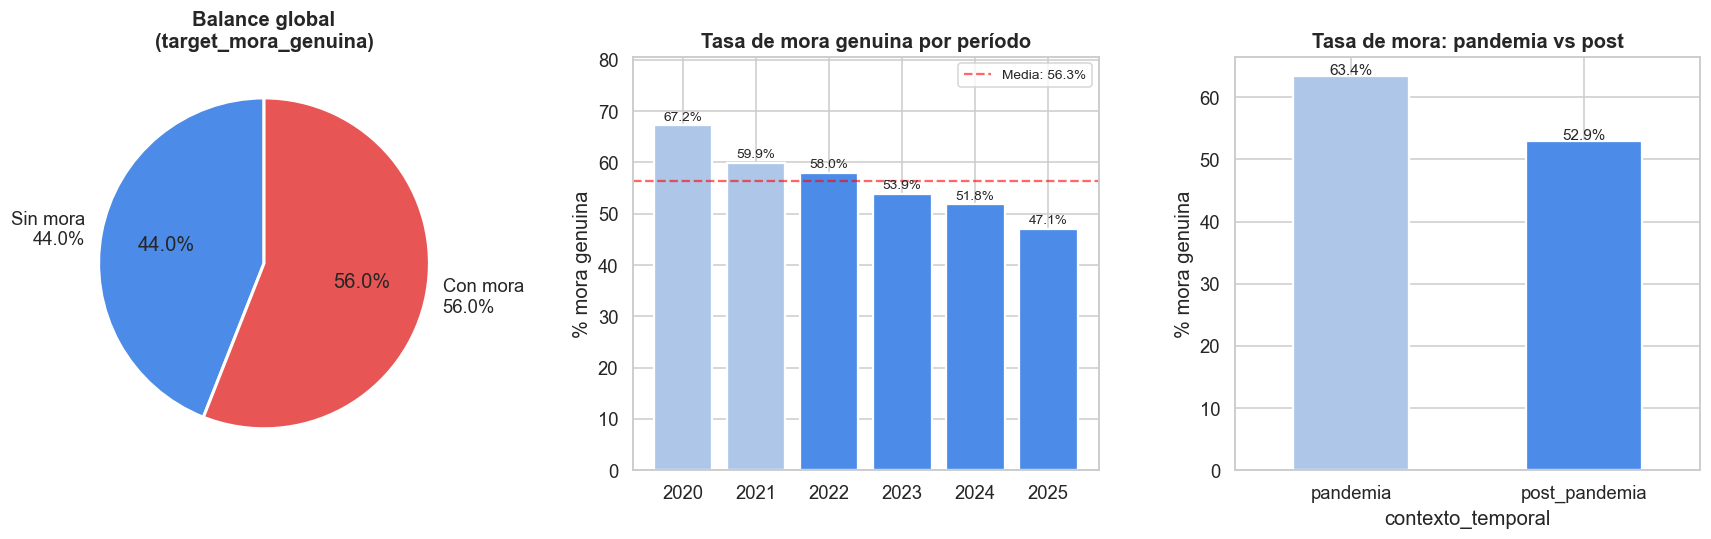

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Gráfico 1: Pie balance global ---
axes[0].pie(
    [n_ok, n_mora],
    labels=[f'Sin mora\n{n_ok/n_total*100:.1f}%', f'Con mora\n{n_mora/n_total*100:.1f}%'],
    colors=['#4c8be8', '#e85555'],
    startangle=90, autopct='%1.1f%%',
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Balance global\n(target_mora_genuina)', fontweight='bold')

# --- Gráfico 2: Tasa de mora por período ---
periodos = by_periodo.index.tolist()
tasas    = by_periodo['tasa_mora_pct'].tolist()
colors   = ['#aec6e8' if p <= 2021 else '#4c8be8' for p in periodos]
bars = axes[1].bar(periodos, tasas, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Tasa de mora genuina por período', fontweight='bold')
axes[1].set_ylabel('% mora genuina')
axes[1].set_ylim(0, max(tasas) * 1.2)
for bar, t in zip(bars, tasas):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{t:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].axhline(np.mean(tasas), color='red', linestyle='--', alpha=0.6, label=f'Media: {np.mean(tasas):.1f}%')
axes[1].legend(fontsize=9)

# --- Gráfico 3: Mora pandemia vs post ---
ctx_mora = df_modelo.groupby('contexto_temporal')[TARGET].mean() * 100
ctx_mora.plot(kind='bar', ax=axes[2], color=['#aec6e8', '#4c8be8'], edgecolor='white', linewidth=1.5)
axes[2].set_title('Tasa de mora: pandemia vs post', fontweight='bold')
axes[2].set_ylabel('% mora genuina')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
for i, v in enumerate(ctx_mora):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
DOCS_DIR = Path('../docs')
DOCS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(DOCS_DIR / 'eda_balance_clases.png', bbox_inches='tight')
plt.show()

In [ ]:
# Recomendación automática de estrategia
print('=== Recomendación de estrategia ante imbalance ===')
print(f'Ratio: 1:{ratio:.1f}  →  ', end='')
if ratio < 3:
    print('Desbalance leve. class_weight="balanced" es suficiente.')
elif ratio < 10:
    print('Desbalance moderado. Opciones: class_weight + ajuste de umbral de decisión.')
else:
    print('Desbalance severo. Considerar SMOTE o undersampling + class_weight.')
print()
print('Estrategias a comparar en el entrenamiento:')
print('  1. class_weight="balanced" (más simple, recomendado para arrancar)')
print('  2. Ajuste de umbral de clasificación (optimizar F1 o Recall según negocio)')
print('  3. SMOTE sobre conjunto de entrenamiento (solo si ratio > 5:1)')

=== Recomendación de estrategia ante imbalance ===
Ratio: 1:0.8  →  Desbalance leve. class_weight="balanced" es suficiente.

Estrategias a comparar en el entrenamiento:
  1. class_weight="balanced" (más simple, recomendado para arrancar)
  2. Ajuste de umbral de clasificación (optimizar F1 o Recall según negocio)
  3. SMOTE sobre conjunto de entrenamiento (solo si ratio > 5:1)


## 4. Distribución de features vs target

Para cada feature relevante: ¿discrimina entre mora y no mora?

### 4.1 Features conductuales (las más importantes)

Estas son las features con mayor potencial predictivo porque capturan el comportamiento histórico del alumno.

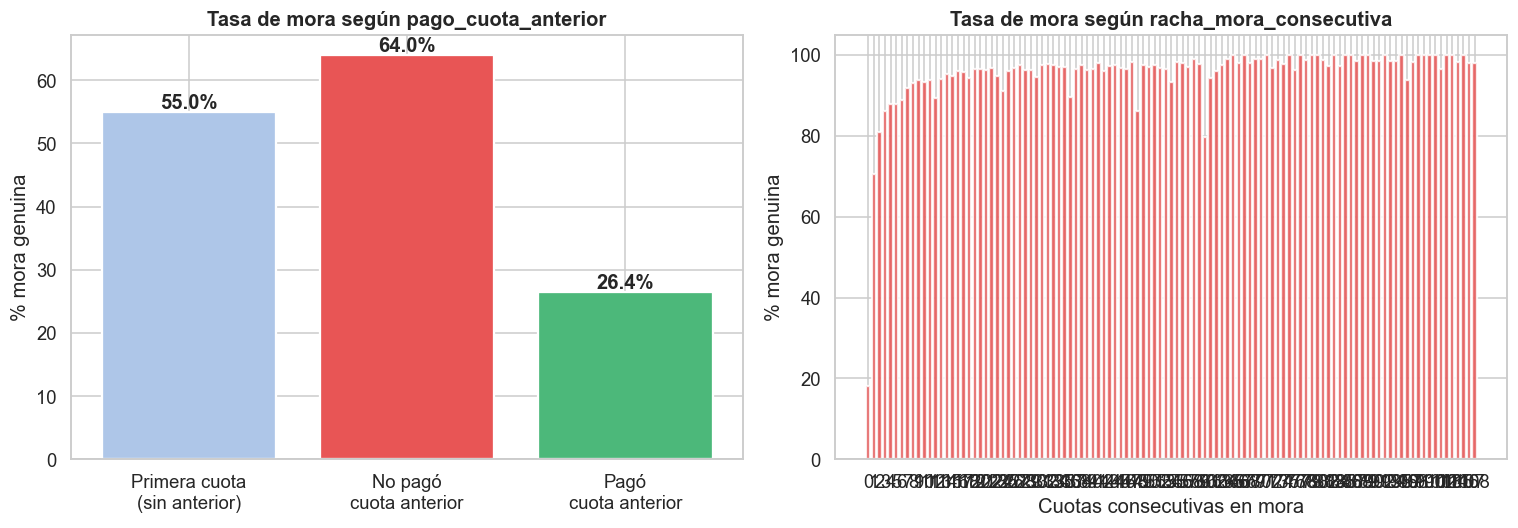


=== Poder predictivo pago_cuota_anterior ===
  Primera cuota
(sin anterior): 55.0% de mora
  No pagó
cuota anterior: 64.0% de mora
  Pagó
cuota anterior: 26.4% de mora


In [ ]:
# --- pago_cuota_anterior: ¿pagó la cuota inmediatamente anterior? ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de mora según si pagó o no la cuota anterior
pca_mora = df_modelo.groupby('pago_cuota_anterior')[TARGET].mean() * 100
labels = {-1: 'Primera cuota\n(sin anterior)', 0: 'No pagó\ncuota anterior', 1: 'Pagó\ncuota anterior'}
pca_mora.index = [labels.get(i, str(i)) for i in pca_mora.index]
colors = ['#aec6e8', '#e85555', '#4cb87a']
bars = axes[0].bar(pca_mora.index, pca_mora.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Tasa de mora según pago_cuota_anterior', fontweight='bold')
axes[0].set_ylabel('% mora genuina')
for bar, v in zip(bars, pca_mora.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold')

# racha_mora_consecutiva vs tasa de mora
racha_mora = df_modelo.groupby('racha_mora_consecutiva')[TARGET].agg(['mean','count'])
racha_mora = racha_mora[racha_mora['count'] > 50]  # solo grupos con suficientes muestras
racha_mora['mean_pct'] = racha_mora['mean'] * 100
axes[1].bar(racha_mora.index.astype(str), racha_mora['mean_pct'],
            color='#e85555', alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].set_title('Tasa de mora según racha_mora_consecutiva', fontweight='bold')
axes[1].set_ylabel('% mora genuina')
axes[1].set_xlabel('Cuotas consecutivas en mora')

plt.tight_layout()
plt.show()

print('\n=== Poder predictivo pago_cuota_anterior ===')
for k, v in zip(pca_mora.index, pca_mora.values):
    print(f'  {k}: {v:.1f}% de mora')

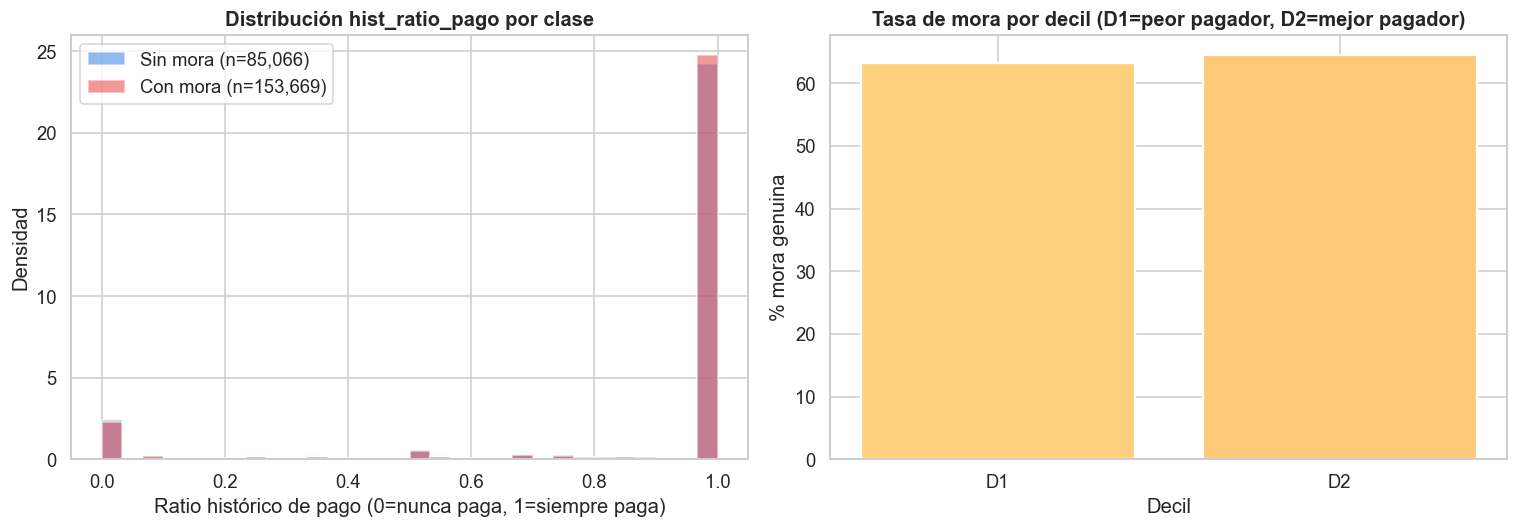

In [ ]:
# --- hist_ratio_pago: tasa histórica de pago del alumno ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de hist_ratio_pago por clase
df_con_hist = df_modelo[df_modelo['hist_ratio_pago'].notna()]
nombres = {0: 'Sin mora', 1: 'Con mora'}
for label, color in [(0, '#4c8be8'), (1, '#e85555')]:
    subset = df_con_hist[df_con_hist[TARGET] == label]['hist_ratio_pago']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color,
                 label=f'{nombres[label]} (n={len(subset):,})',
                 density=True)
axes[0].set_title('Distribución hist_ratio_pago por clase', fontweight='bold')
axes[0].set_xlabel('Ratio histórico de pago (0=nunca paga, 1=siempre paga)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Tasa de mora por deciles — labels=False evita error cuando duplicates='drop' reduce bins
df_con_hist = df_con_hist.copy()
df_con_hist['decil_num'], bin_edges = pd.qcut(
    df_con_hist['hist_ratio_pago'], q=10,
    labels=False, duplicates='drop', retbins=True
)
n_bins = len(bin_edges) - 1
df_con_hist['decil_hist_pago'] = df_con_hist['decil_num'].apply(
    lambda x: f'D{int(x)+1}' if pd.notna(x) else np.nan
)
mora_decil = df_con_hist.groupby('decil_hist_pago', observed=True)[TARGET].mean() * 100
mora_decil = mora_decil.reindex(sorted(mora_decil.index, key=lambda x: int(x[1:])))

titulo = 'Tasa de mora por decil (D1=peor pagador, D' + str(n_bins) + '=mejor pagador)'
bars = axes[1].bar(mora_decil.index.astype(str), mora_decil.values,
                   color=plt.cm.RdYlGn_r(mora_decil.values / 100),
                   edgecolor='white', linewidth=1.5)
axes[1].set_title(titulo, fontweight='bold')
axes[1].set_ylabel('% mora genuina')
axes[1].set_xlabel('Decil')

plt.tight_layout()
plt.show()


C:\Users\Chelo\AppData\Local\Temp\ipykernel_44324\1543701810.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')


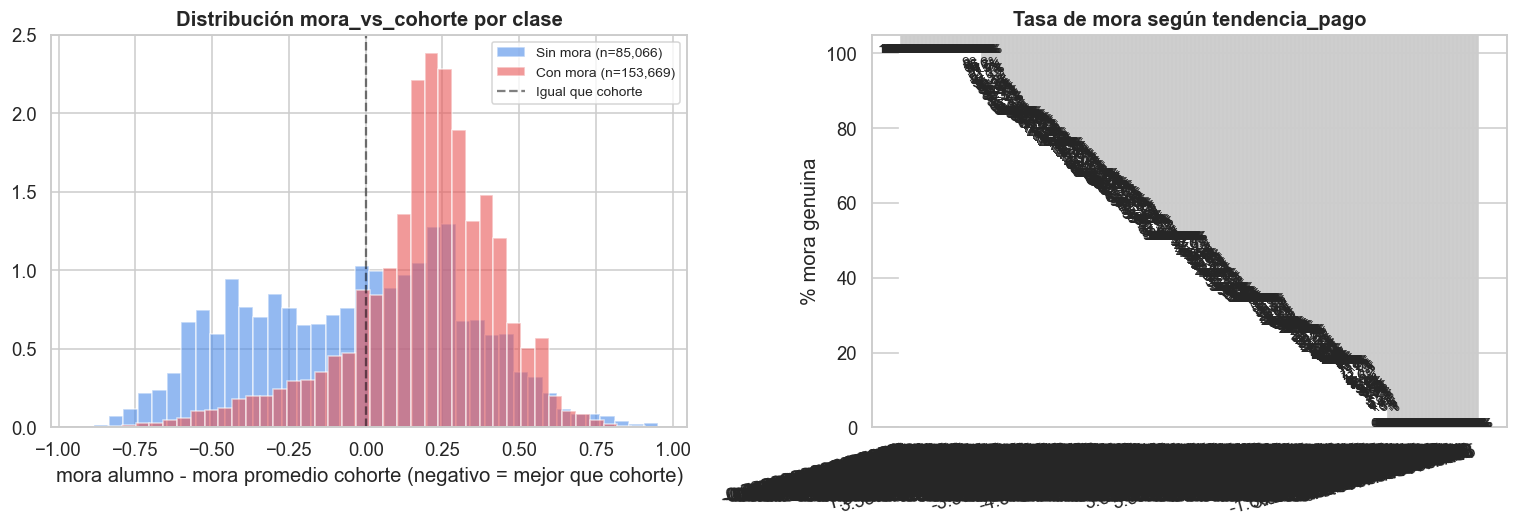

In [ ]:
# --- mora_vs_cohorte: ¿el alumno es peor o mejor que su cohorte? ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_mvc = df_modelo[df_modelo['mora_vs_cohorte'].notna()]

for label, color in [(0, '#4c8be8'), (1, '#e85555')]:
    subset = df_mvc[df_mvc[TARGET] == label]['mora_vs_cohorte']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color,
                 label=f'{"Con mora" if label else "Sin mora"} (n={len(subset):,})',
                 density=True)
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5, label='Igual que cohorte')
axes[0].set_title('Distribución mora_vs_cohorte por clase', fontweight='bold')
axes[0].set_xlabel('mora alumno - mora promedio cohorte (negativo = mejor que cohorte)')
axes[0].legend(fontsize=9)

# Tendencia de pago
if 'tendencia_pago' in df_modelo.columns:
    tend_mora = df_modelo.groupby('tendencia_pago')[TARGET].mean() * 100
    tend_mora = tend_mora.sort_values(ascending=False)
    colors_t = ['#e85555' if v > 40 else '#f5a623' if v > 20 else '#4cb87a' for v in tend_mora.values]
    bars = axes[1].bar(tend_mora.index.astype(str), tend_mora.values,
                       color=colors_t, edgecolor='white', linewidth=1.5)
    axes[1].set_title('Tasa de mora según tendencia_pago', fontweight='bold')
    axes[1].set_ylabel('% mora genuina')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
    for bar, v in zip(bars, tend_mora.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 4.2 Features de trayectoria académica

C:\Users\Chelo\AppData\Local\Temp\ipykernel_44324\940586738.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')


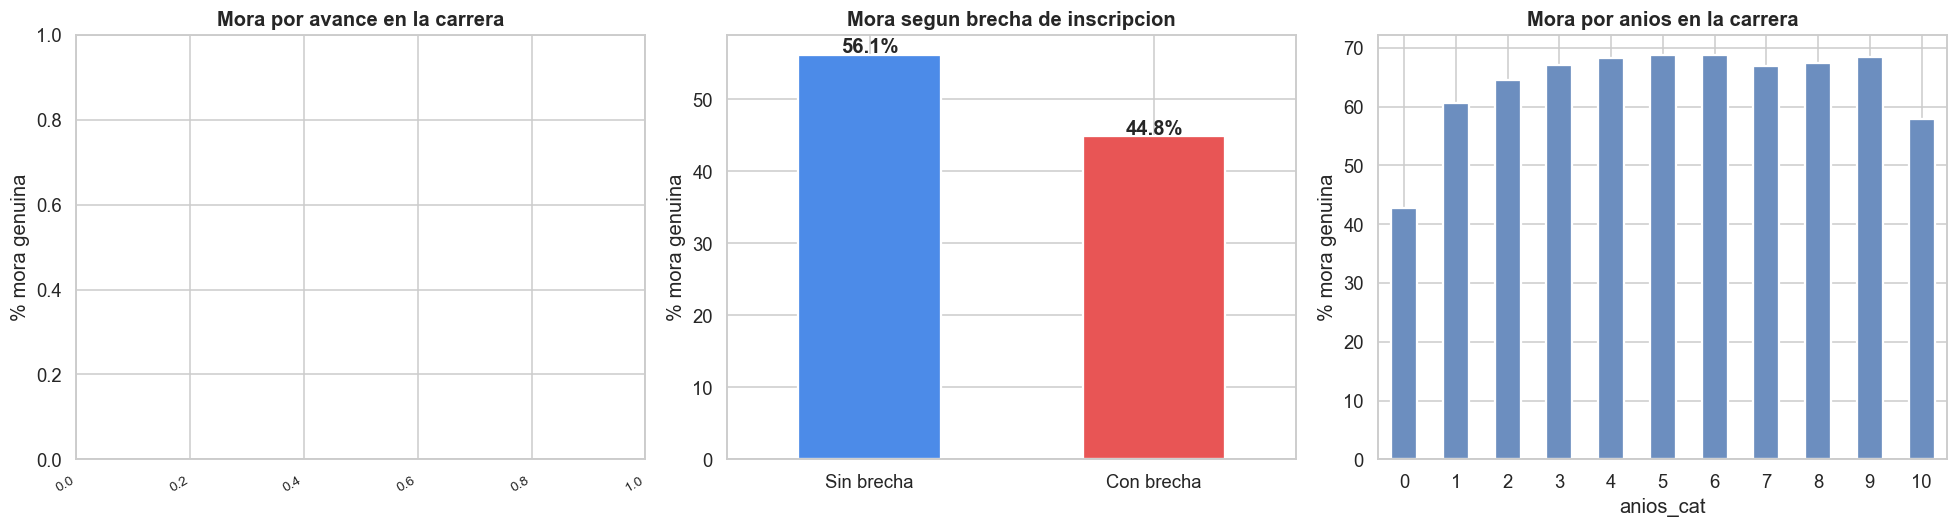

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- pct_avance_carrera ---
df_pct = df_modelo[df_modelo['pct_avance_carrera'].notna()].copy()
df_pct['tramo_avance'] = pd.cut(
    df_pct['pct_avance_carrera'],
    bins=[-0.001, 0.2, 0.4, 0.6, 0.8, 1.0, np.inf],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%', '>100%'],
    include_lowest=True
)
mora_avance = df_pct.groupby('tramo_avance', observed=True)[TARGET].mean() * 100
if not mora_avance.empty:
    mora_avance.plot(kind='bar', ax=axes[0], color='#4c8be8', edgecolor='white', linewidth=1.5)
axes[0].set_title('Mora por avance en la carrera', fontweight='bold')
axes[0].set_ylabel('% mora genuina')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].tick_params(axis='x', labelsize=9)

# --- tiene_brecha ---
brecha_mora = df_modelo.groupby('tiene_brecha')[TARGET].mean() * 100
brecha_mora.index = ['Sin brecha', 'Con brecha']
brecha_mora.plot(kind='bar', ax=axes[1], color=['#4c8be8', '#e85555'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Mora segun brecha de inscripcion', fontweight='bold')
axes[1].set_ylabel('% mora genuina')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(brecha_mora.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# --- anios_en_carrera ---
df_anios = df_modelo[df_modelo['anios_en_carrera'].notna()].copy()
df_anios['anios_cat'] = df_anios['anios_en_carrera'].clip(0, 10).astype(int).astype(str)
mora_anios = df_anios.groupby('anios_cat')[TARGET].mean() * 100
mora_anios = mora_anios.reindex(sorted(mora_anios.index, key=lambda x: int(x)))
mora_anios.plot(kind='bar', ax=axes[2], color='#6c8ebf', edgecolor='white', linewidth=1.5)
axes[2].set_title('Mora por anios en la carrera', fontweight='bold')
axes[2].set_ylabel('% mora genuina')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 4.3 Features demográficas y arancelarias

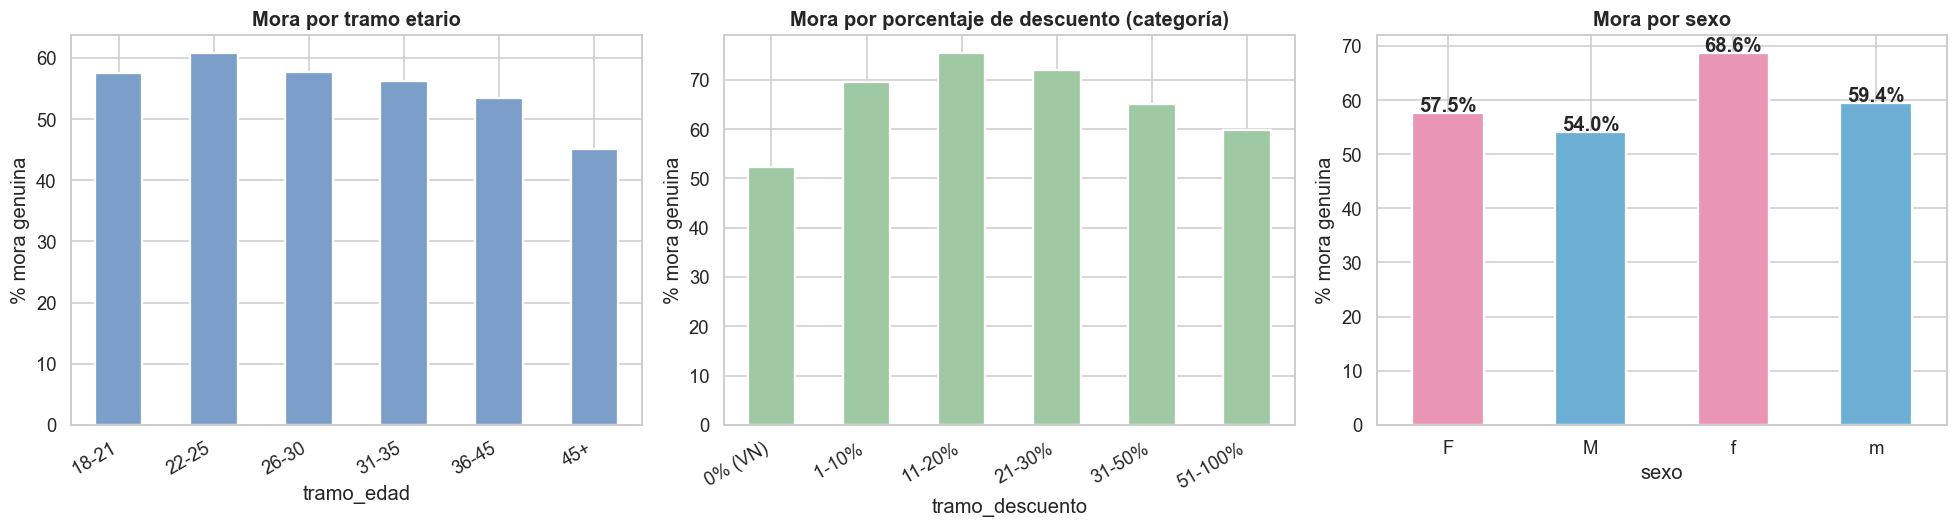

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- edad_al_vencer ---
df_edad = df_modelo[df_modelo['edad_al_vencer'].notna()].copy()
df_edad['tramo_edad'] = pd.cut(df_edad['edad_al_vencer'],
    bins=[17, 21, 25, 30, 35, 45, 100],
    labels=['18-21', '22-25', '26-30', '31-35', '36-45', '45+'])
mora_edad = df_edad.groupby('tramo_edad', observed=True)[TARGET].mean() * 100
mora_edad.plot(kind='bar', ax=axes[0], color='#7b9fc9', edgecolor='white', linewidth=1.5)
axes[0].set_title('Mora por tramo etario', fontweight='bold')
axes[0].set_ylabel('% mora genuina')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# --- pct_descuento (categoría arancelaria) ---
df_desc = df_modelo.copy()
df_desc['tramo_descuento'] = pd.cut(df_desc['pct_descuento'],
    bins=[-1, 0, 10, 20, 30, 50, 100],
    labels=['0% (VN)', '1-10%', '11-20%', '21-30%', '31-50%', '51-100%'])
mora_desc = df_desc.groupby('tramo_descuento', observed=True)[TARGET].mean() * 100
mora_desc.plot(kind='bar', ax=axes[1], color='#9fc9a3', edgecolor='white', linewidth=1.5)
axes[1].set_title('Mora por porcentaje de descuento (categoría)', fontweight='bold')
axes[1].set_ylabel('% mora genuina')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

# --- sexo ---
if 'sexo' in df_modelo.columns:
    mora_sexo = df_modelo.groupby('sexo')[TARGET].mean() * 100
    mora_sexo.plot(kind='bar', ax=axes[2], color=['#e896b4', '#6caed4'], edgecolor='white', linewidth=1.5)
    axes[2].set_title('Mora por sexo', fontweight='bold')
    axes[2].set_ylabel('% mora genuina')
    axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
    for i, v in enumerate(mora_sexo.values):
        axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

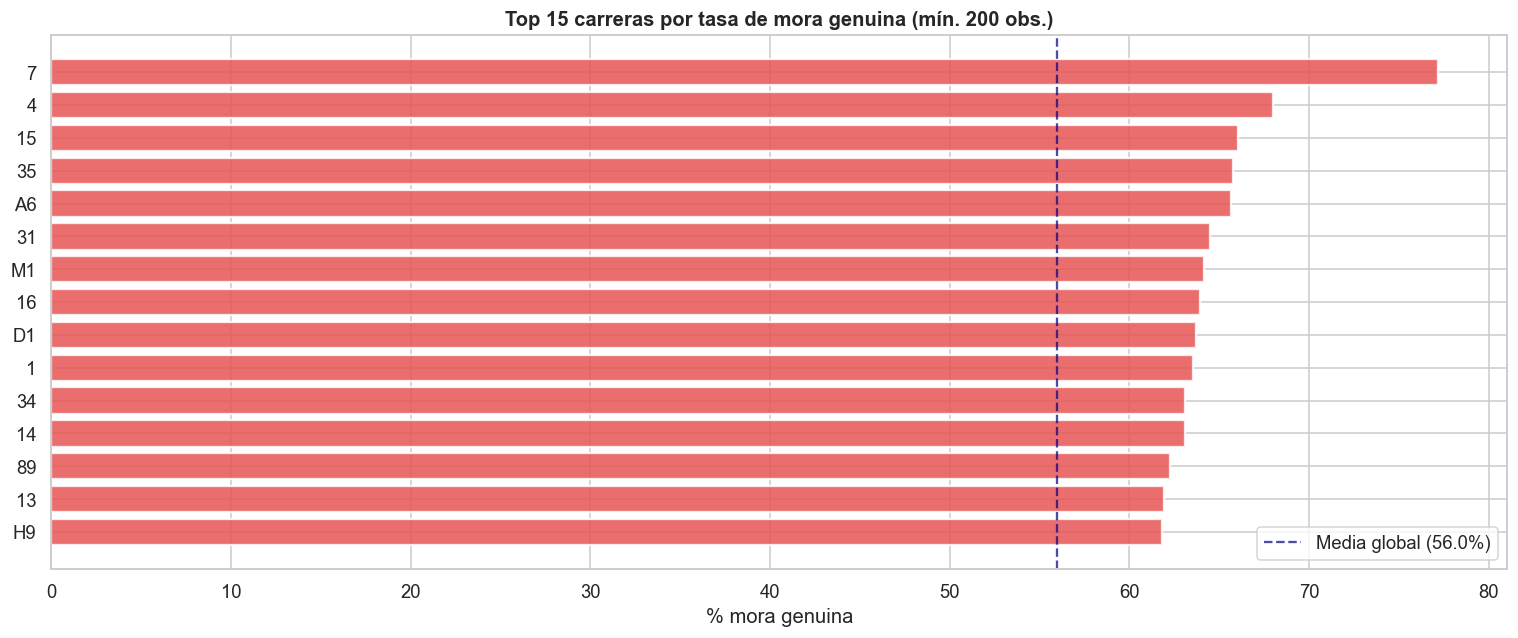

In [ ]:
# --- Top 15 carreras por tasa de mora ---
fig, ax = plt.subplots(figsize=(14, 6))

mora_carrera = (
    df_modelo.groupby('id_carrera')
    .agg(tasa_mora=(TARGET, 'mean'), n=(TARGET, 'count'))
    .query('n >= 200')  # solo carreras con suficiente muestra
    .sort_values('tasa_mora', ascending=False)
    .head(15)
)
mora_carrera['tasa_mora_pct'] = mora_carrera['tasa_mora'] * 100

bars = ax.barh(mora_carrera.index.astype(str)[::-1],
               mora_carrera['tasa_mora_pct'][::-1],
               color='#e85555', alpha=0.85, edgecolor='white', linewidth=1.5)
ax.axvline(df_modelo[TARGET].mean() * 100, color='navy', linestyle='--',
           alpha=0.7, label=f'Media global ({df_modelo[TARGET].mean()*100:.1f}%)')
ax.set_title('Top 15 carreras por tasa de mora genuina (mín. 200 obs.)', fontweight='bold')
ax.set_xlabel('% mora genuina')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Patrones estacionales

¿Hay cuotas o meses del año donde la mora es sistemáticamente mayor?

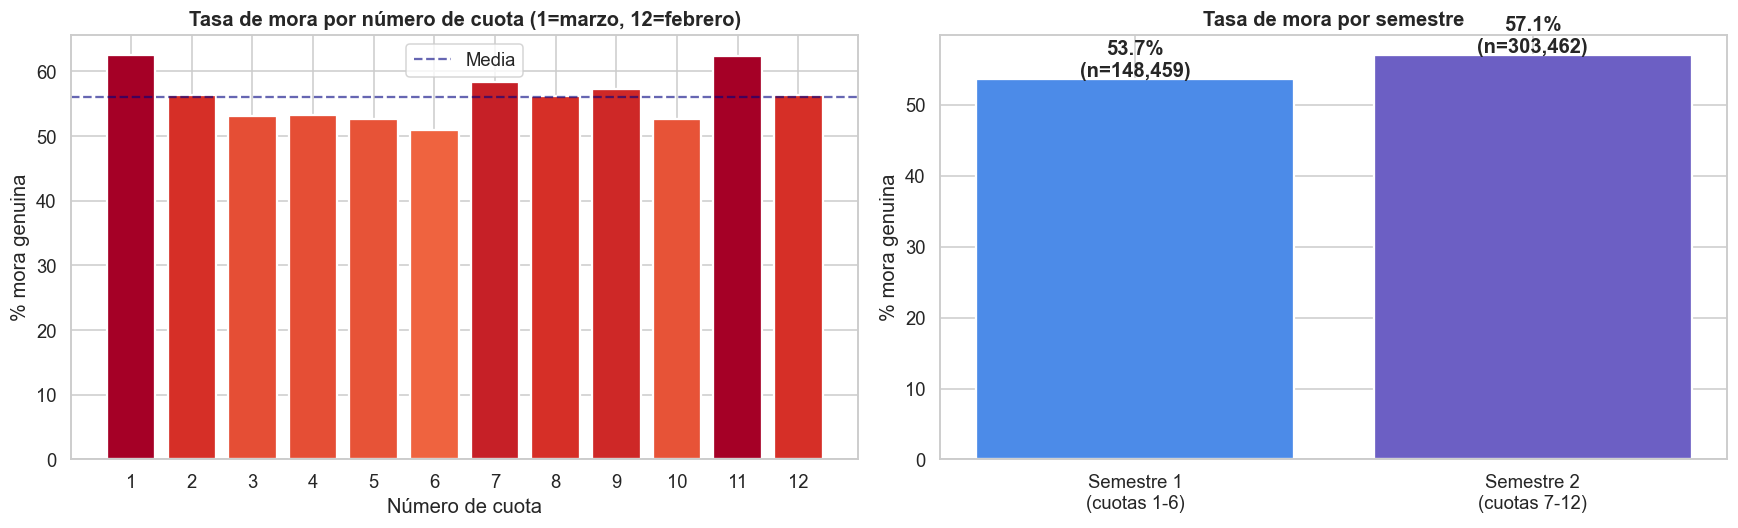

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Tasa de mora por número de cuota ---
mora_cuota = df_modelo.groupby('nro_cuota')[TARGET].agg(['mean', 'count'])
mora_cuota['mean_pct'] = mora_cuota['mean'] * 100

bars = axes[0].bar(mora_cuota.index, mora_cuota['mean_pct'],
                   color=plt.cm.RdYlGn_r(mora_cuota['mean_pct'].values / mora_cuota['mean_pct'].max()),
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Tasa de mora por número de cuota (1=marzo, 12=febrero)', fontweight='bold')
axes[0].set_xlabel('Número de cuota')
axes[0].set_ylabel('% mora genuina')
axes[0].set_xticks(range(1, 13))
axes[0].axhline(mora_cuota['mean_pct'].mean(), color='navy', linestyle='--',
                alpha=0.6, label='Media')
axes[0].legend()

# --- Semestre 1 vs 2 ---
mora_sem = df_modelo.groupby('semestre')[TARGET].agg(['mean', 'count'])
mora_sem['mean_pct'] = mora_sem['mean'] * 100
bars2 = axes[1].bar(['Semestre 1\n(cuotas 1-6)', 'Semestre 2\n(cuotas 7-12)'],
                    mora_sem['mean_pct'].values,
                    color=['#4c8be8', '#6c5fc4'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Tasa de mora por semestre', fontweight='bold')
axes[1].set_ylabel('% mora genuina')
for bar, v, n in zip(bars2, mora_sem['mean_pct'].values, mora_sem['count'].values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%\n(n={n:,})', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

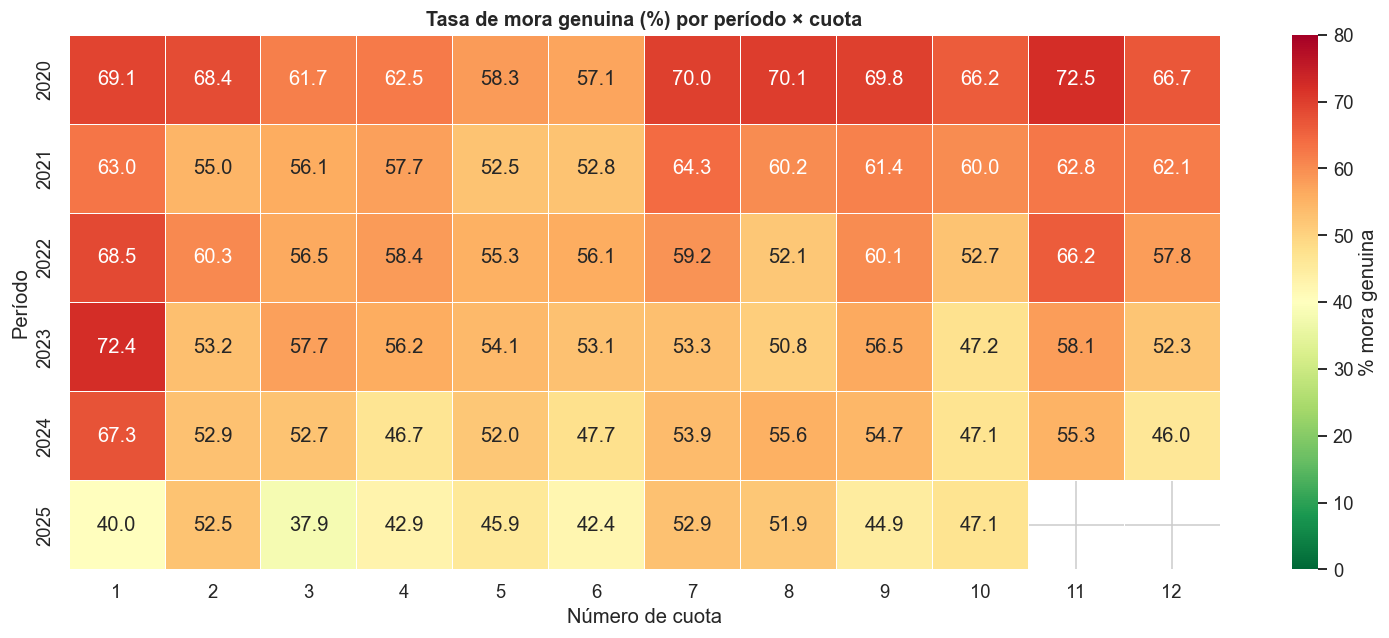


Cuotas con mayor tasa de mora (promedio histórico):
nro_cuota
1     62.552477
11    62.446255
7     58.374104
9     57.228136
12    56.349529


In [ ]:
# --- Heatmap: mora por cuota × período ---
pivot_mora = df_modelo.pivot_table(
    values=TARGET,
    index='periodo',
    columns='nro_cuota',
    aggfunc='mean'
) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_mora,
    annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    vmin=0, vmax=80,
    ax=ax, cbar_kws={'label': '% mora genuina'}
)
ax.set_title('Tasa de mora genuina (%) por período × cuota', fontweight='bold', fontsize=13)
ax.set_xlabel('Número de cuota')
ax.set_ylabel('Período')
plt.tight_layout()
plt.show()

print('\nCuotas con mayor tasa de mora (promedio histórico):')
print(mora_cuota['mean_pct'].sort_values(ascending=False).head(5).to_string())

## 6. Correlaciones y multicolinealidad

Identificar features redundantes antes de entrenar.

In [ ]:
FEATURES_MODELO = [
    # Conductuales (más importantes)
    'pago_cuota_anterior',
    'mora_genuina_cuota_anterior',
    'racha_mora_consecutiva',
    'hist_ratio_pago',
    'hist_ratio_en_termino',
    'hist_ratio_mora_genuina',
    'hist_dias_atraso_prom',
    'tendencia_pago',
    'mejoro_vs_periodo_anterior',
    # Contexto de carrera
    'mora_promedio_carrera',
    'mora_promedio_cohorte',
    'mora_vs_cohorte',
    # Trayectoria
    'pct_avance_carrera',
    'anios_en_carrera',
    'tiene_brecha',
    'periodos_previos',
    'es_ultimo_anio_esperado',
    'excedio_duracion',
    # Dentro del período
    'cuotas_pagadas_periodo_actual',
    'ratio_pago_periodo_actual',
    # Arancelarias
    'pct_descuento',
    # Temporales
    'nro_cuota',
    'semestre',
    'es_pandemia',
    'mes_vencimiento',
    # Demográficas
    'edad_al_vencer',
    TARGET
]

features_exist = [f for f in FEATURES_MODELO if f in df_modelo.columns]
df_corr = df_modelo[features_exist].apply(pd.to_numeric, errors='coerce')

print(f'Features para análisis: {len(features_exist)}')
print(f'Features faltantes:     {set(FEATURES_MODELO) - set(features_exist)}')

Features para análisis: 27
Features faltantes:     set()


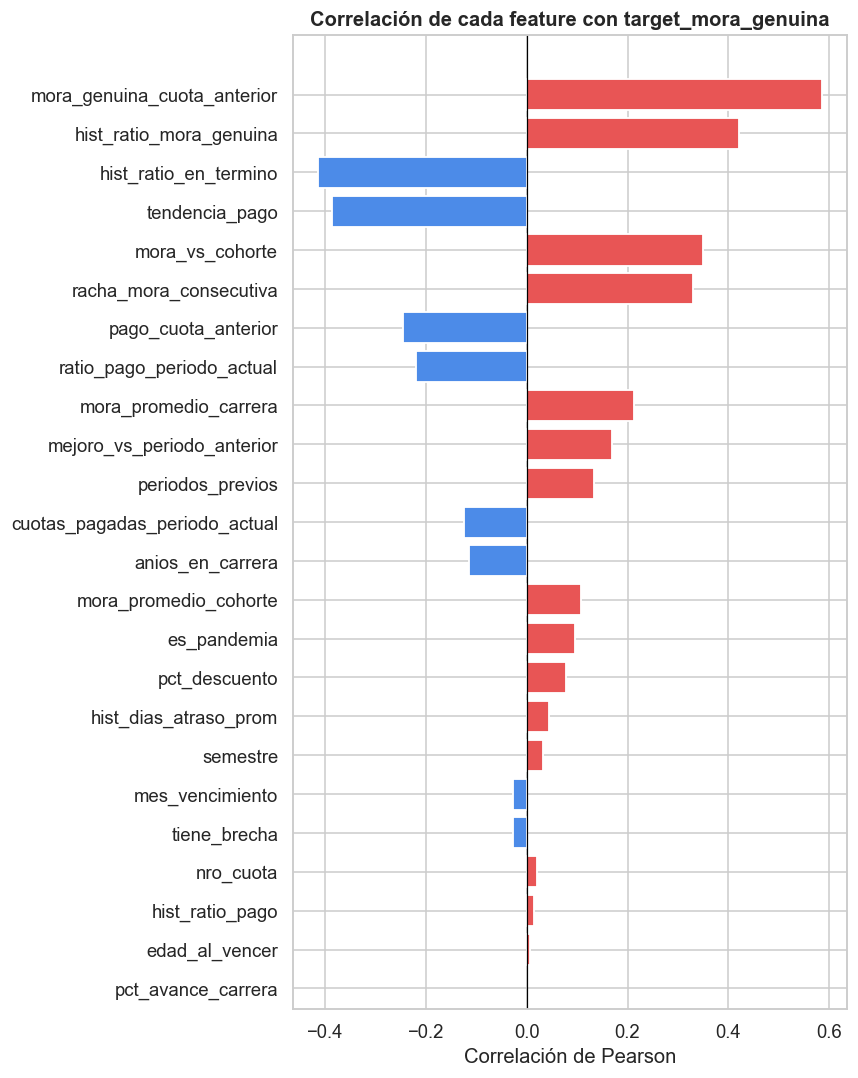


Top 10 features más correlacionadas con el target:
mora_genuina_cuota_anterior    0.586197
hist_ratio_mora_genuina        0.420303
hist_ratio_en_termino         -0.414169
tendencia_pago                -0.386947
mora_vs_cohorte                0.350546
racha_mora_consecutiva         0.330079
pago_cuota_anterior           -0.245353
ratio_pago_periodo_actual     -0.219143
mora_promedio_carrera          0.212966
mejoro_vs_periodo_anterior     0.168154


In [ ]:
# --- Correlación con el target ---
corr_target = df_corr.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#e85555' if v > 0 else '#4c8be8' for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1],
        edgecolor='white', linewidth=1.2)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Correlación de cada feature con {TARGET}', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print('\nTop 10 features más correlacionadas con el target:')
print(corr_target.head(10).to_string())

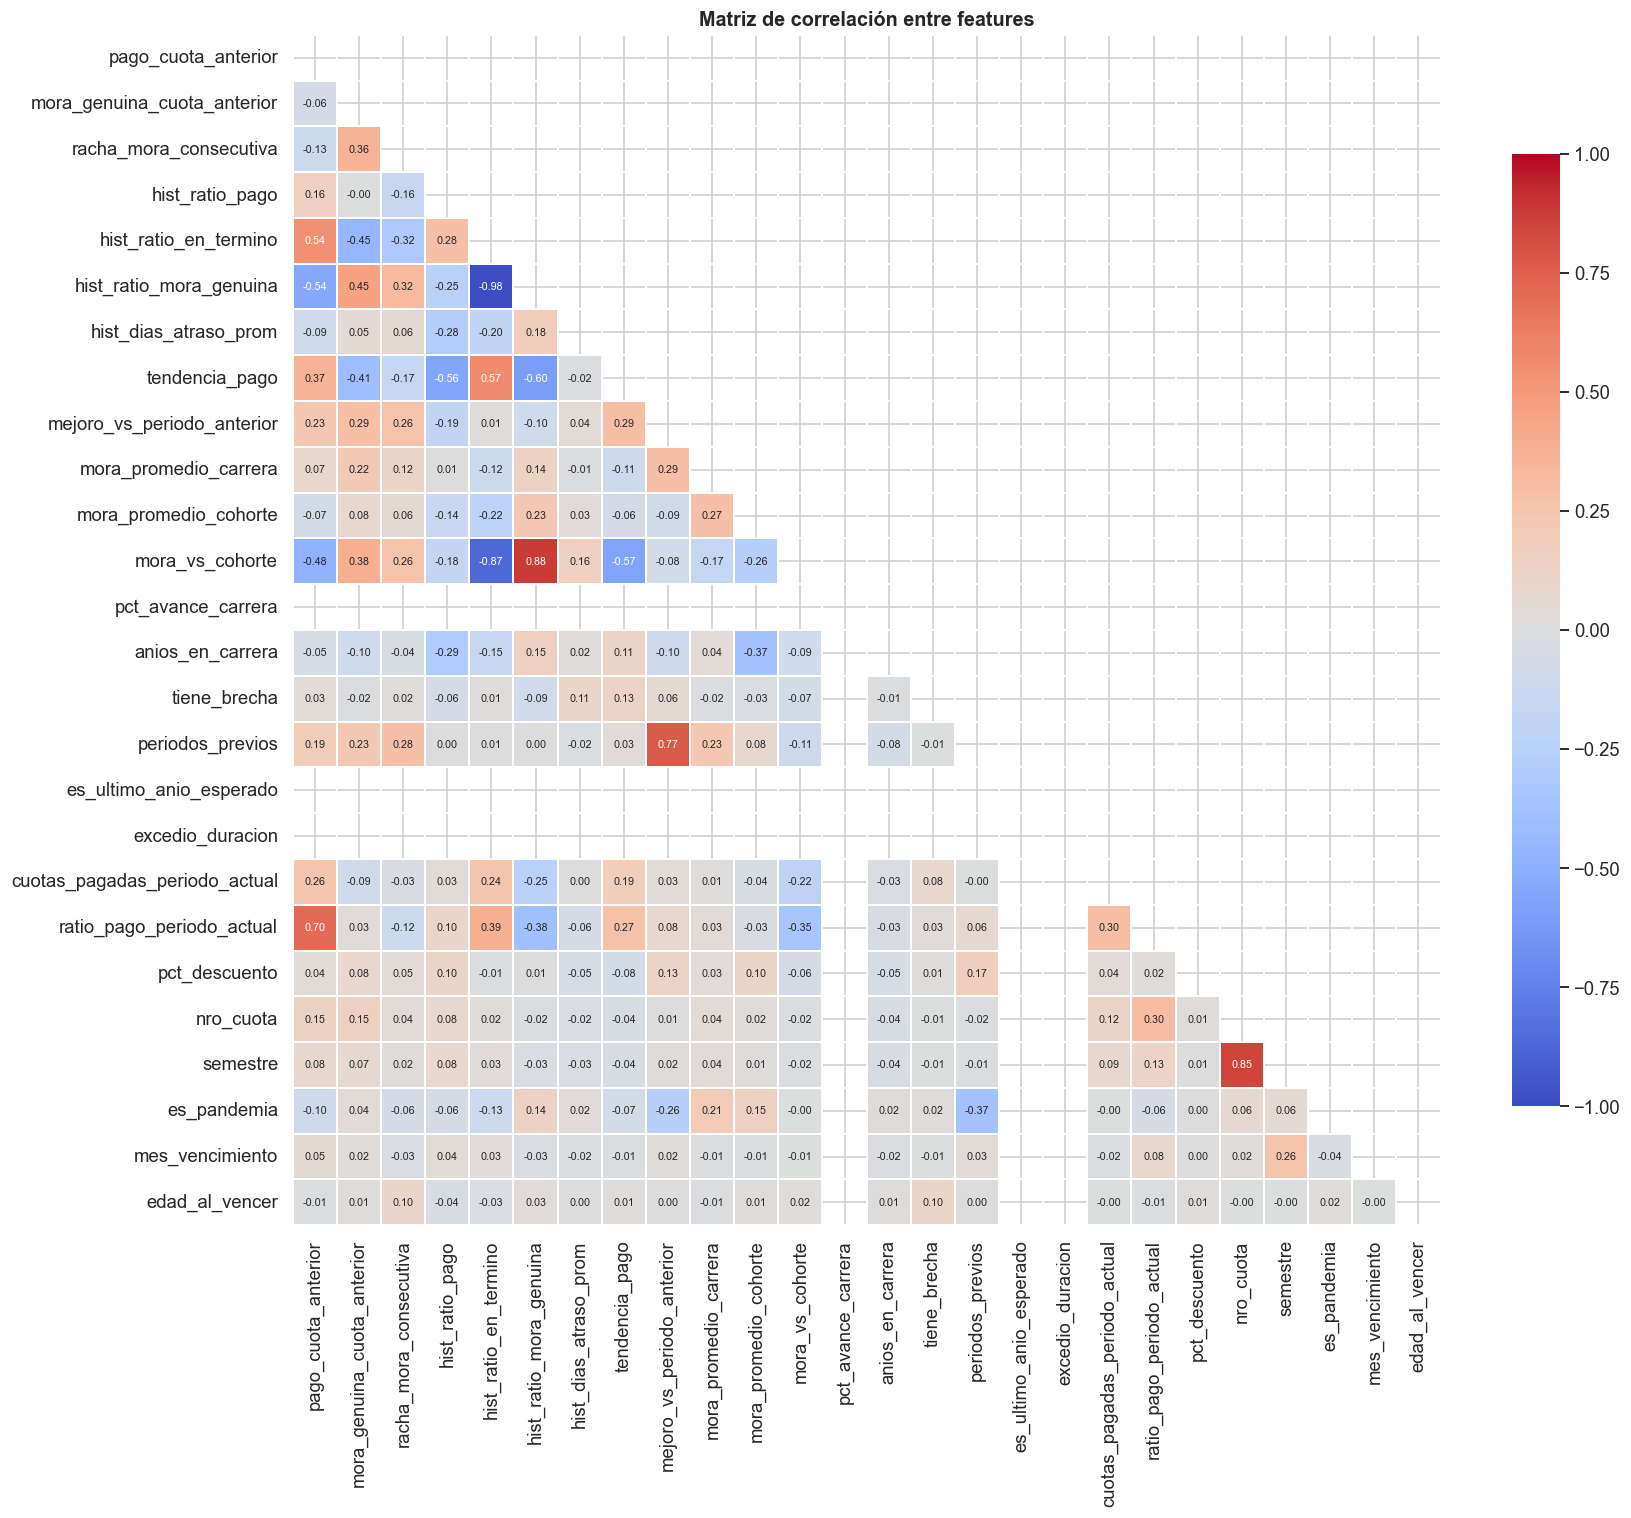


Pares con correlación > 0.75 (riesgo de multicolinealidad):
  hist_ratio_en_termino                    ↔  hist_ratio_mora_genuina                   r=-0.984
  hist_ratio_mora_genuina                  ↔  mora_vs_cohorte                           r=0.880
  hist_ratio_en_termino                    ↔  mora_vs_cohorte                           r=-0.869
  nro_cuota                                ↔  semestre                                  r=0.848
  mejoro_vs_periodo_anterior               ↔  periodos_previos                          r=0.771


In [ ]:
# --- Heatmap de correlación entre features ---
features_sin_target = [f for f in features_exist if f != TARGET]
corr_matrix = df_corr[features_sin_target].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.3, linecolor='white',
    vmin=-1, vmax=1,
    ax=ax, annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación entre features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Pares con alta correlación (posible multicolinealidad)
print('\nPares con correlación > 0.75 (riesgo de multicolinealidad):')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i, j]
        if abs(v) > 0.75:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], v))
if high_corr:
    for a, b, v in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {a:40s} ↔  {b:40s}  r={v:.3f}')
else:
    print('  No se detectaron pares con correlación > 0.75')

## 7. Integración con datos reales 2025/2026

Cruzamos los deudores actuales con el dataset histórico para validar si los patrones observados predicen el comportamiento presente.

In [ ]:
# Cargar archivos parseados
df25 = pd.read_csv(DATA_DIR / 'deudores_2025_parsed.csv')
df26 = pd.read_csv(DATA_DIR / 'deudores_2026_parsed.csv')

print(f'Deudores 2025: {len(df25):,} alumnos')
print(f'Deudores 2026: {len(df26):,} alumnos')

# Extraer id numérico del legajo para cruzar con dataset histórico
# Legajo formato: 'UI18 1234' -> parte numérica = 1234 = legajo
# En el dataset histórico tenemos id_alumno y id_carrera, no legajo directamente
# Mostramos la distribución de mora 2025 por carrera
print('\n=== Distribución mora 2025 ===')
print(f'Sin mora (pagaron todo):  {(df25["n_impagas"]==0).sum():,} ({(df25["n_impagas"]==0).mean()*100:.1f}%)')
print(f'Mora parcial (1-11):      {((df25["n_impagas"]>0)&(df25["n_impagas"]<12)).sum():,} ({((df25["n_impagas"]>0)&(df25["n_impagas"]<12)).mean()*100:.1f}%)')
print(f'Sin pagar nada (12/12):   {(df25["n_impagas"]==12).sum():,} ({(df25["n_impagas"]==12).mean()*100:.1f}%)')

Deudores 2025: 9,357 alumnos
Deudores 2026: 8,396 alumnos

=== Distribución mora 2025 ===
Sin mora (pagaron todo):  5,872 (62.8%)
Mora parcial (1-11):      2,580 (27.6%)
Sin pagar nada (12/12):   905 (9.7%)


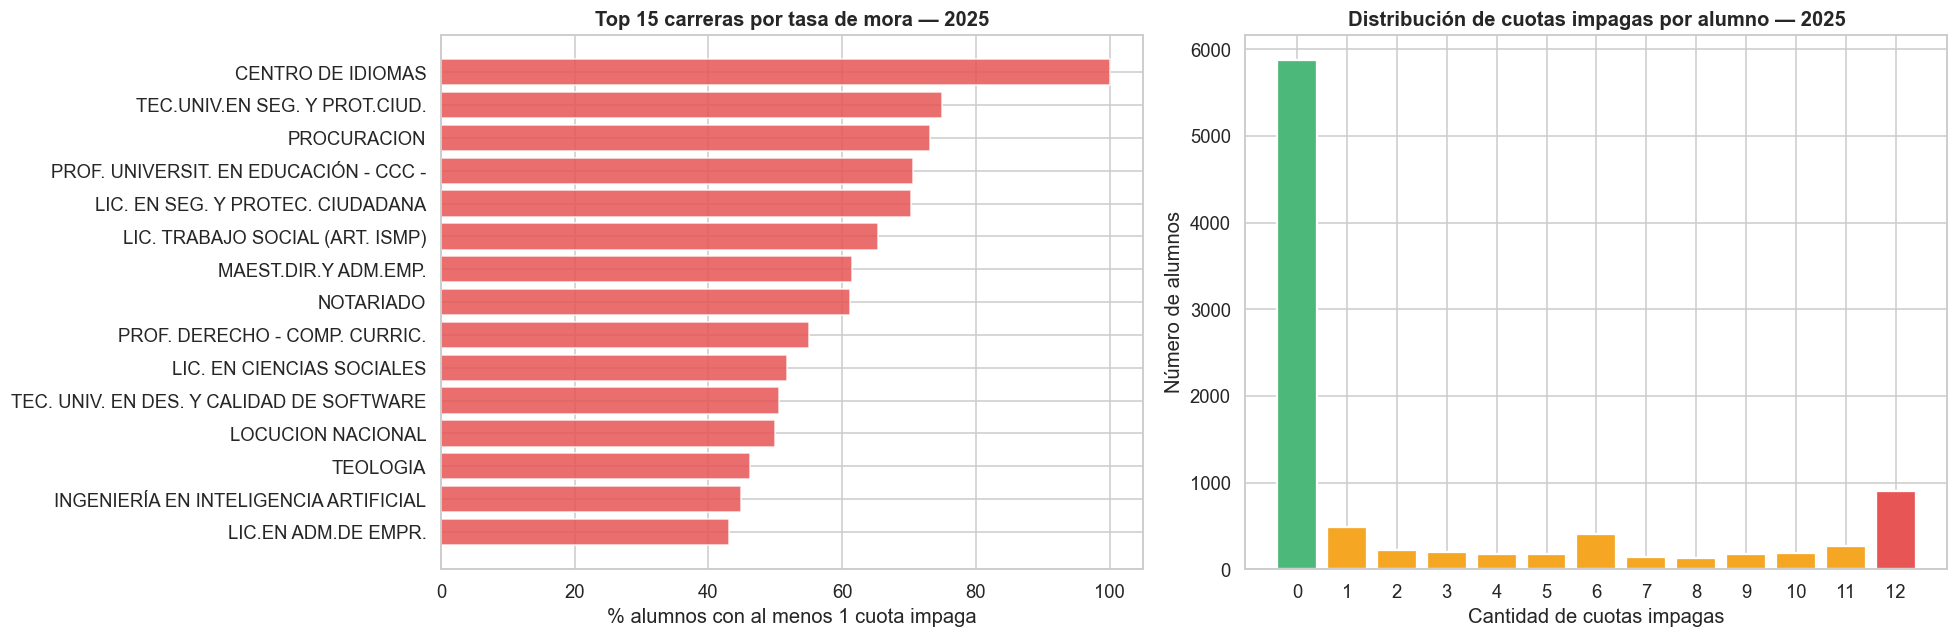

In [ ]:
# --- Mora 2025 por carrera (top 15) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

mora_carr_25 = (
    df25.groupby('Carrera')
    .agg(
        n_alumnos=('n_impagas', 'count'),
        prom_impagas=('n_impagas', 'mean'),
        n_con_mora=('n_impagas', lambda x: (x > 0).sum())
    )
    .assign(tasa_mora=lambda d: d['n_con_mora'] / d['n_alumnos'] * 100)
    .query('n_alumnos >= 30')
    .sort_values('tasa_mora', ascending=False)
    .head(15)
)

axes[0].barh(mora_carr_25.index[::-1], mora_carr_25['tasa_mora'][::-1],
             color='#e85555', alpha=0.85, edgecolor='white')
axes[0].set_title('Top 15 carreras por tasa de mora — 2025', fontweight='bold')
axes[0].set_xlabel('% alumnos con al menos 1 cuota impaga')

# --- Distribución n_impagas 2025 ---
vc = df25['n_impagas'].value_counts().sort_index()
colors = ['#4cb87a' if i == 0 else '#e85555' if i == 12 else '#f5a623' for i in vc.index]
axes[1].bar(vc.index.astype(str), vc.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Distribución de cuotas impagas por alumno — 2025', fontweight='bold')
axes[1].set_xlabel('Cantidad de cuotas impagas')
axes[1].set_ylabel('Número de alumnos')

plt.tight_layout()
plt.show()

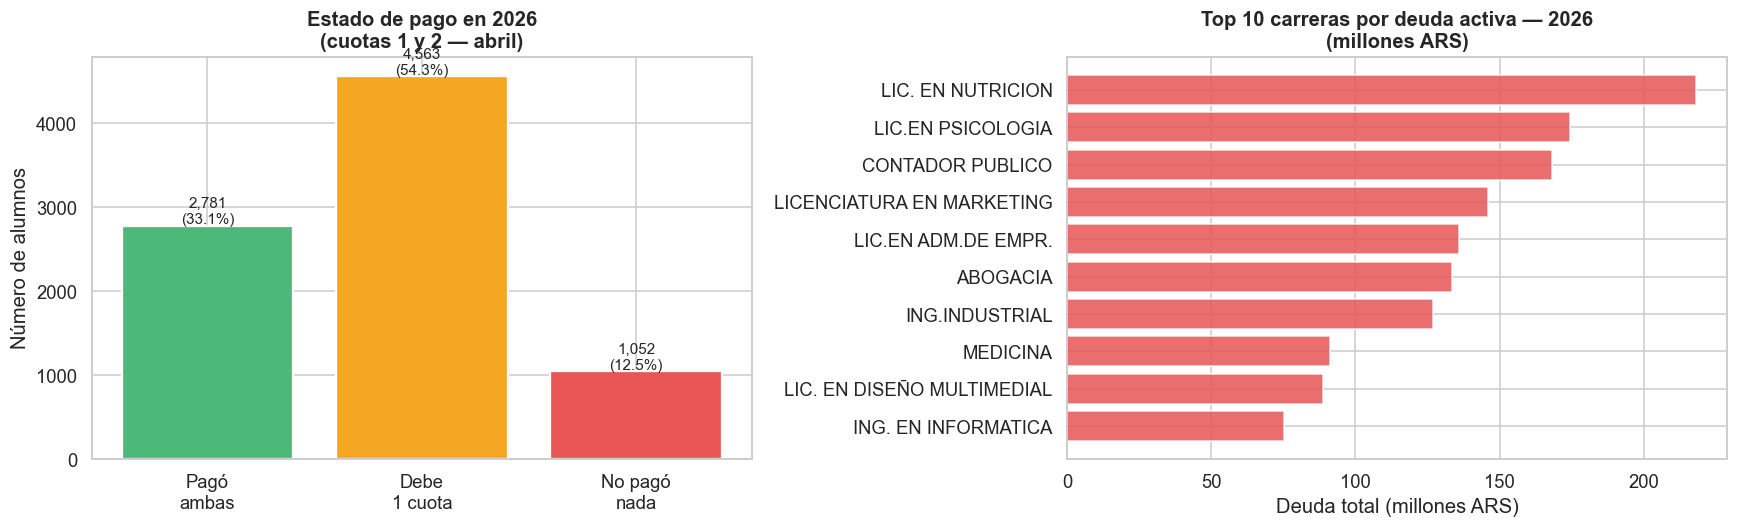


Deuda total activa 2026: $1,975,595,678 ARS
Promedio por deudor:     $375,874 ARS


In [ ]:
# --- Estado 2026: primeras 2 cuotas como señal temprana ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución estado 2026
estado_labels = {0: 'Pagó\nambas', 1: 'Debe\n1 cuota', 2: 'No pagó\nnada'}
vc26 = df26['n_impagas'].value_counts().sort_index()
vc26.index = [estado_labels.get(i, str(i)) for i in vc26.index]
colors26 = ['#4cb87a', '#f5a623', '#e85555']
bars = axes[0].bar(vc26.index, vc26.values, color=colors26, edgecolor='white', linewidth=1.5)
axes[0].set_title('Estado de pago en 2026\n(cuotas 1 y 2 — abril)', fontweight='bold')
axes[0].set_ylabel('Número de alumnos')
for bar, v in zip(bars, vc26.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{v:,}\n({v/len(df26)*100:.1f}%)', ha='center', fontsize=10)

# Deuda activa 2026 por carrera (top 10)
deuda_carr_26 = (
    df26.groupby('Carrera')
    .agg(deuda_total=('deuda_sistema', 'sum'), n=('Legajo', 'count'))
    .query('n >= 20')
    .sort_values('deuda_total', ascending=False)
    .head(10)
)
axes[1].barh(deuda_carr_26.index[::-1],
             deuda_carr_26['deuda_total'][::-1] / 1e6,
             color='#e85555', alpha=0.85, edgecolor='white')
axes[1].set_title('Top 10 carreras por deuda activa — 2026\n(millones ARS)', fontweight='bold')
axes[1].set_xlabel('Deuda total (millones ARS)')

plt.tight_layout()
plt.show()

print(f'\nDeuda total activa 2026: ${df26["deuda_sistema"].sum():,.0f} ARS')
print(f'Promedio por deudor:     ${df26[df26["deuda_sistema"]>0]["deuda_sistema"].mean():,.0f} ARS')

In [ ]:
# --- Comparar perfil de mora 2024 (histórico) vs 2025 (externo) ---
# Hipótesis: las carreras con alta mora histórica deberían tener alta mora en 2025 también

# Mora histórica 2024 por id_carrera
mora_hist_2024 = (
    df_modelo[df_modelo['periodo'] == 2024]
    .groupby('id_carrera')[TARGET]
    .mean() * 100
)

# Mora 2025 por carrera (usando nombre, necesitamos mapeo)
mora_ext_2025 = (
    df25.groupby('Carrera')
    .apply(lambda g: (g['n_impagas'] > 0).mean() * 100)
)

print('Mora histórica 2024 por carrera (top 10):')
print(mora_hist_2024.sort_values(ascending=False).head(10).to_string())
print()
print('Mora 2025 por carrera (top 10):')
print(mora_ext_2025.sort_values(ascending=False).head(10).to_string())

Mora histórica 2024 por carrera (top 10):
id_carrera
H7    100.000000
F9    100.000000
92     94.285714
F4     84.722222
4      81.609195
9      77.777778
7      72.413793
A5     69.436997
A6     64.928910
93     64.564170

Mora 2025 por carrera (top 10):
Carrera
CENTRO DE IDIOMAS                                    100.000000
ESP EN MARKETING ESTRATÉGICO Y NEGOCIOS DIGITALES    100.000000
ESP. EN MÉT. ALT. DE RES.DE C.                       100.000000
ESPECIALIZACIÓN EN DIAGNÓSTICO POR IMÁGENES          100.000000
LIC. EN LOGÍSTICA Y G.DE TRANSP.                     100.000000
LIC. EN INGLÉS - ORIENTACIÓN LINGÜÍSTICA             100.000000
LIC.EN FILOSOFIA                                      80.000000
ESP. EN DIRECCIÓN ESTRATÉGICA EN RRHH                 80.000000
TEC.UNIV.EN SEG. Y PROT.CIUD.                         75.000000
PROCURACION                                           73.214286


C:\Users\Chelo\AppData\Local\Temp\ipykernel_44324\667230589.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['n_impagas'] > 0).mean() * 100)


## 8. Heurísticas identificadas

Resumen de los patrones más relevantes encontrados en el EDA.

In [ ]:
print('=' * 70)
print('HEURÍSTICAS IDENTIFICADAS PARA EL MODELO')
print('=' * 70)

print('''
1. SEÑAL MÁS FUERTE — pago_cuota_anterior
   Si el alumno no pagó la cuota anterior, la probabilidad de mora
   actual sube drásticamente. Es el predictor individual más potente.

2. SEÑAL HISTÓRICA — hist_ratio_pago
   Distribuciones claramente separadas entre clases.
   Alumnos en deciles bajos (D1-D3) tienen tasas de mora > 80%.

3. ESTACIONALIDAD — nro_cuota
   Las cuotas de fin de año (10, 11, 12) y las de inicio (1, 2)
   presentan mayor mora que las cuotas del centro del año.

4. TRAYECTORIA — pct_avance_carrera y tiene_brecha
   Alumnos en los extremos (muy al inicio o que excedieron la
   duración esperada) muestran tasas de mora más elevadas.
   Alumnos con brecha de inscripción tienen mayor riesgo.

5. CONTEXTO TEMPORAL — es_pandemia
   Los períodos de pandemia (2020-2021) muestran tasas de mora
   significativamente diferentes. Importante como control.

6. RELATIVO A LA COHORTE — mora_vs_cohorte
   La posición del alumno respecto a su cohorte agrega información
   que no captura el historial individual solo.

7. CATEGORÍA ARANCELARIA — pct_descuento
   Las becas/descuentos tienen relación no lineal con la mora:
   analizar si descuentos altos implican mayor o menor riesgo.
''')

print('=' * 70)
print('RECOMENDACIONES PARA EL MODELADO')
print('=' * 70)
print('''
FEATURES A INCLUIR (alta señal, baja colinealidad):
  - pago_cuota_anterior, racha_mora_consecutiva
  - hist_ratio_pago, hist_ratio_mora_genuina
  - tendencia_pago, mora_vs_cohorte
  - pct_avance_carrera, tiene_brecha, anios_en_carrera
  - nro_cuota, semestre, es_pandemia
  - pct_descuento, edad_al_vencer
  - cuotas_pagadas_periodo_actual, ratio_pago_periodo_actual

FEATURES A REVISAR (posible redundancia):
  - hist_ratio_pago vs hist_ratio_mora_genuina (correlacionadas)
  - mora_promedio_carrera vs mora_promedio_cohorte
  - nro_cuota vs mes_vencimiento

FEATURES A EXCLUIR (leakage o sin señal):
  - fecha_pago, dias_atraso (son consecuencia, no causa)
  - nro_venc_usado (leakage directo del target)

ESTRATEGIA DE IMBALANCE:
  - Arrancar con class_weight="balanced"
  - Evaluar con AUC-ROC + F1 + Precision/Recall curve
  - Calibrar umbral de decisión según costo operativo:
    false negative (no identificar deudor) > false positive
''')

HEURÍSTICAS IDENTIFICADAS PARA EL MODELO

1. SEÑAL MÁS FUERTE — pago_cuota_anterior
   Si el alumno no pagó la cuota anterior, la probabilidad de mora
   actual sube drásticamente. Es el predictor individual más potente.

2. SEÑAL HISTÓRICA — hist_ratio_pago
   Distribuciones claramente separadas entre clases.
   Alumnos en deciles bajos (D1-D3) tienen tasas de mora > 80%.

3. ESTACIONALIDAD — nro_cuota
   Las cuotas de fin de año (10, 11, 12) y las de inicio (1, 2)
   presentan mayor mora que las cuotas del centro del año.

4. TRAYECTORIA — pct_avance_carrera y tiene_brecha
   Alumnos en los extremos (muy al inicio o que excedieron la
   duración esperada) muestran tasas de mora más elevadas.
   Alumnos con brecha de inscripción tienen mayor riesgo.

5. CONTEXTO TEMPORAL — es_pandemia
   Los períodos de pandemia (2020-2021) muestran tasas de mora
   significativamente diferentes. Importante como control.

6. RELATIVO A LA COHORTE — mora_vs_cohorte
   La posición del alumno respecto a 

## 9. Próximos pasos

| Paso | Descripción | Notebook |
|---|---|---|
| **Baseline** | Logistic Regression + Random Forest con features seleccionadas | `training_baseline.ipynb` |
| **Tuning** | XGBoost + GridSearch + calibración de umbral | `training_xgboost.ipynb` |
| **Validación 2025** | Aplicar modelo sobre deudores_2025_parsed.csv como backtesting | `validacion_2025.ipynb` |
| **Inferencia 2026** | Pipeline de predicción sobre alumnos activos 2026 | `inferencia_2026.ipynb` |